# 2-Class XGBoost

---



## Step 4: Pridiction - Training, Testing and Evaluation



### Import Necessary Libraries and Load Data

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import xgboost as xgb
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay
)

In [3]:
# 1. 挂载 Google Drive
drive.mount('/content/drive')

# 2. 设置文件路径
data_path = '/content/drive/MyDrive/Colab Notebooks/machine learning'
train_file = os.path.join(data_path, 'train_70.csv')
test_file = os.path.join(data_path, 'test_30.csv')
full_file = os.path.join(data_path, 'full_preprocessed_data.csv')

# 3. 加载数据
print("Datasets Loading...")
train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)
full_df = pd.read_csv(full_file)

Mounted at /content/drive
Datasets Loading...



### Define Target and Features

In [5]:
# 使用 Target_binary 作为目标：Dropout = 1, 非 Dropout = 0
def prepare_xy(df):
    X = df.drop(columns=['Target', 'Target_binary']) # 移除两个目标列作为特征
    y = df['Target_binary']
    return X, y

X_train, y_train = prepare_xy(train_df)
X_test, y_test = prepare_xy(test_df)
X_full, y_full = prepare_xy(full_df)

### Initialize and Train Baseline Model

In [6]:
# 自动计算 scale_pos_weight 以处理不均衡数据
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=ratio,      # 替换原来的 class_weight='balanced' [cite: 278]
    random_state=42,
    eval_metric='logloss'        # 二分类评估指标
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

### Evaluate Baseline Model


==================== Training Set Evaluation ====================
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

Detailed Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       1.00      1.00      1.00      2102
     Dropout       1.00      1.00      1.00       994

    accuracy                           1.00      3096
   macro avg       1.00      1.00      1.00      3096
weighted avg       1.00      1.00      1.00      3096



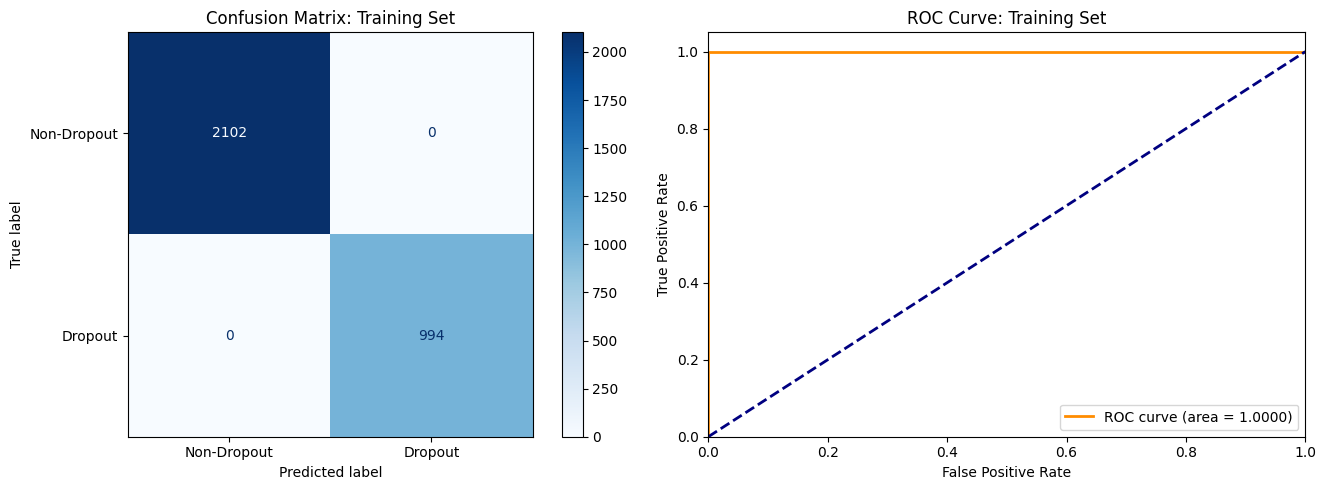


==================== Testing Set Evaluation ====================
Accuracy:  0.8584
Precision: 0.7880
Recall:    0.7658
F1-Score:  0.7767

Detailed Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.89      0.90      0.90       901
     Dropout       0.79      0.77      0.78       427

    accuracy                           0.86      1328
   macro avg       0.84      0.83      0.84      1328
weighted avg       0.86      0.86      0.86      1328



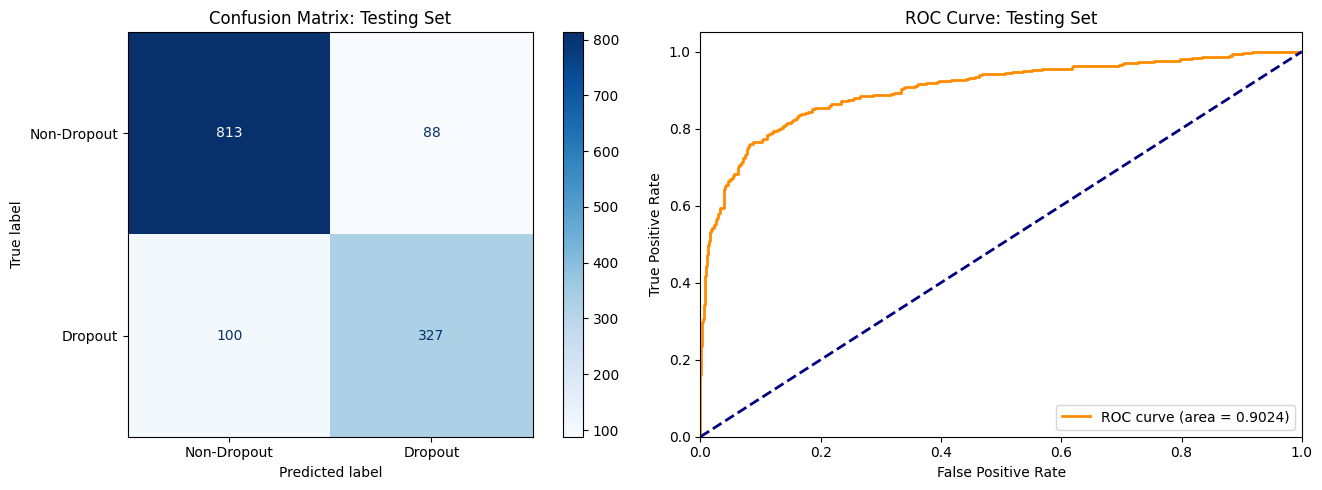


==================== Entire Set Evaluation ====================
Accuracy:  0.9575
Precision: 0.9375
Recall:    0.9296
F1-Score:  0.9336

Detailed Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.97      0.97      0.97      3003
     Dropout       0.94      0.93      0.93      1421

    accuracy                           0.96      4424
   macro avg       0.95      0.95      0.95      4424
weighted avg       0.96      0.96      0.96      4424



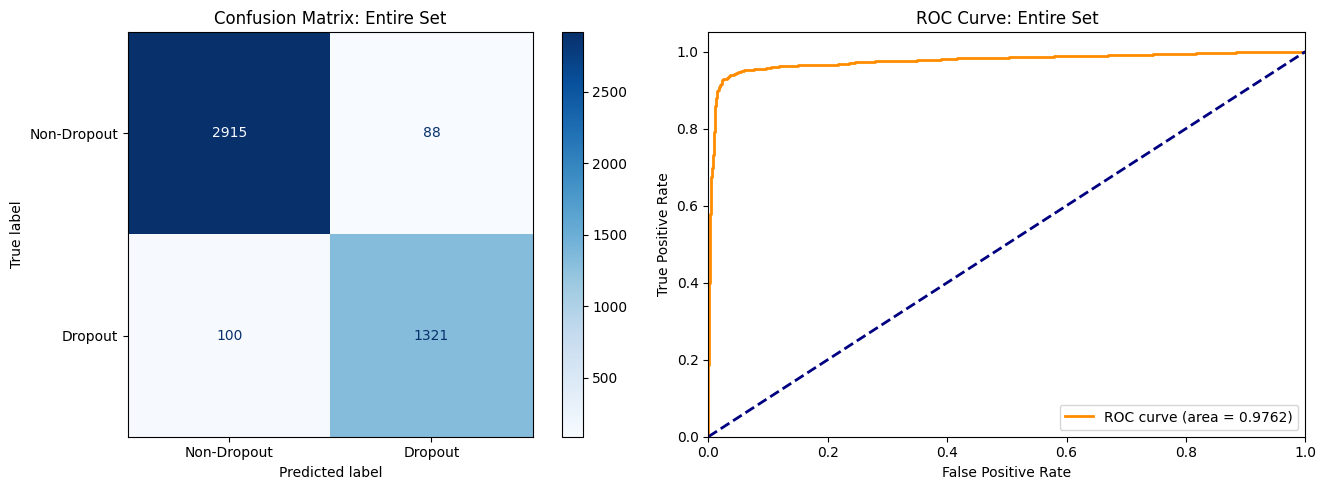


--- Summary of Model Performance ---
Training AUC:   1.0000
Testing AUC:    0.9024
Interpretation: Model shows good generalization (Stable performance across sets).


In [ ]:
def full_evaluation(model, X, y, set_name):
    # Task 4: 获取预测值
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] # 获取预测概率用于 ROC [cite: 85]

    print(f"\n==================== {set_name} Evaluation ====================")

    # Task 5: 计算核心指标 [cite: 84]
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # Task 4: 输出分类报告与混淆矩阵 [cite: 74, 79]
    print("\nDetailed Classification Report:")
    print(classification_report(y, y_pred, target_names=['Non-Dropout', 'Dropout']))

    # 绘制可视化图表 (混淆矩阵 + ROC 曲线)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Confusion Matrix [cite: 79, 84]
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Dropout', 'Dropout'])
    disp.plot(cmap='Blues', ax=ax1)
    ax1.set_title(f"Confusion Matrix: {set_name}")

    # 2. ROC Curve & AUC
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title(f'ROC Curve: {set_name}')
    ax2.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    return roc_auc


train_auc = full_evaluation(xgb_model, X_train, y_train, "Training Set")
test_auc = full_evaluation(xgb_model, X_test, y_test, "Testing Set")
full_auc = full_evaluation(xgb_model, X_full, y_full, "Entire Set")

print("\n--- Summary of Model Performance ---")
print(f"Training AUC:   {train_auc:.4f}")
print(f"Testing AUC:    {test_auc:.4f}")

if (train_auc - test_auc) > 0.1:
    print("Interpretation: Potential Overfitting detected (High gap between Train and Test).")
else:
    print("Interpretation: Model shows good generalization (Stable performance across sets).")

## Step 5 Hyperparameter Tuning

### Get Best Hyperparameters

In [8]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

In [9]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss'),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1', # 针对不平衡数据，F1 通常比 Accuracy 更好
)

grid_search.fit(X_train, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


In [10]:
best_xgb_model = grid_search.best_estimator_

### Final Evaluation on Testing Set


==================== Testing Set Evaluation ====================
Accuracy:  0.8562
Precision: 0.7611
Recall:    0.8056
F1-Score:  0.7827

Detailed Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.91      0.88      0.89       901
     Dropout       0.76      0.81      0.78       427

    accuracy                           0.86      1328
   macro avg       0.83      0.84      0.84      1328
weighted avg       0.86      0.86      0.86      1328



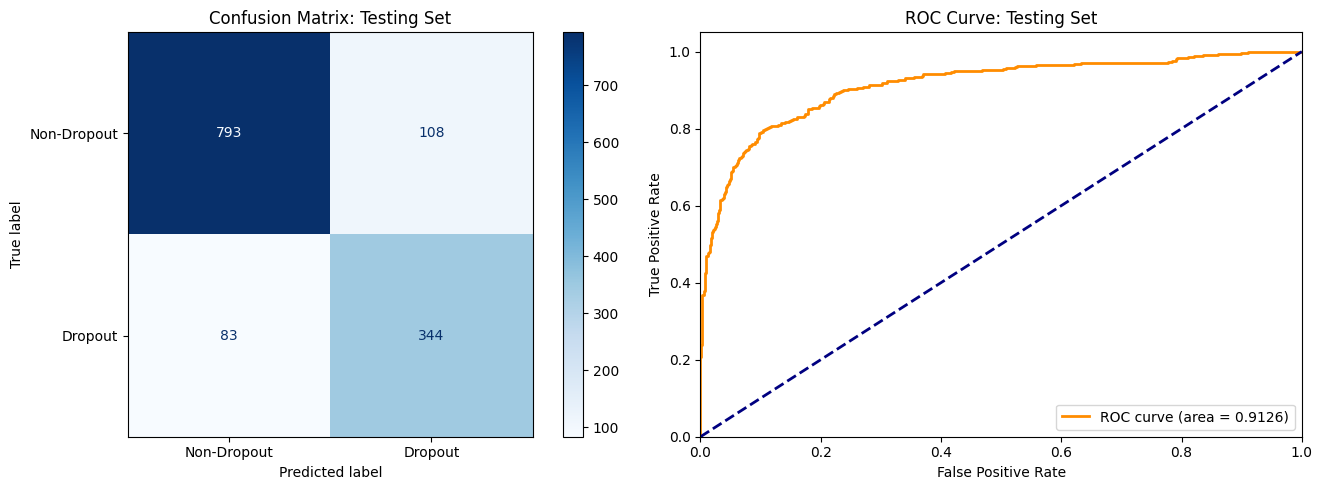


==================== Training Set Evaluation ====================
Accuracy:  0.9031
Precision: 0.8362
Recall:    0.8682
F1-Score:  0.8519

Detailed Classification Report:
              precision    recall  f1-score   support

 Non-Dropout       0.94      0.92      0.93      2102
     Dropout       0.84      0.87      0.85       994

    accuracy                           0.90      3096
   macro avg       0.89      0.89      0.89      3096
weighted avg       0.90      0.90      0.90      3096



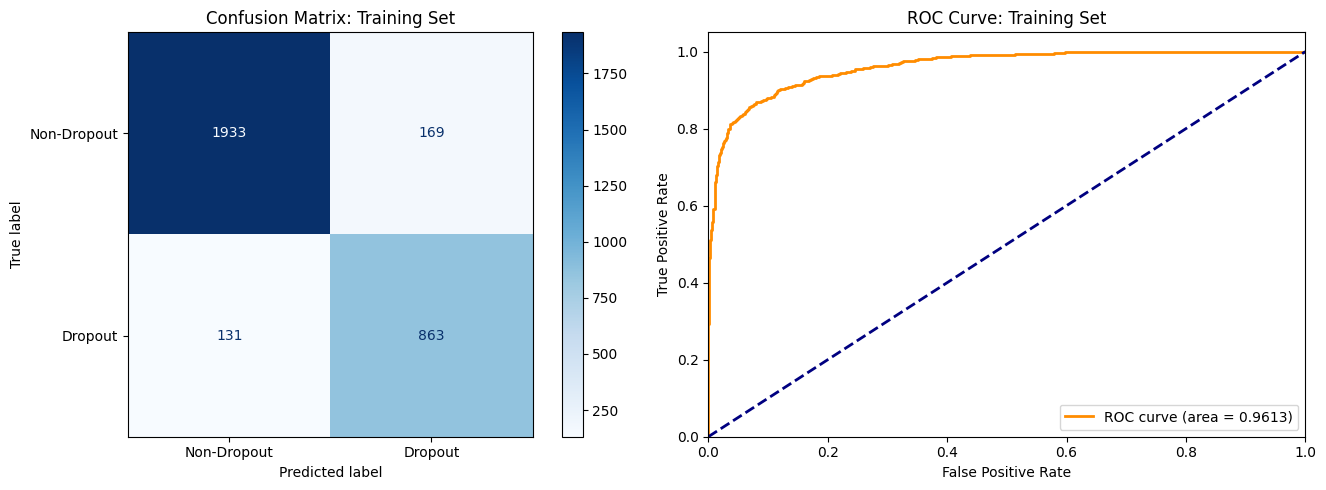

In [ ]:
tuned_auc = full_evaluation(best_xgb_model, X_test, y_test, "Testing Set")
tuned_auc_1 = full_evaluation(best_xgb_model, X_train, y_train, "Training Set")

## Feature Importance

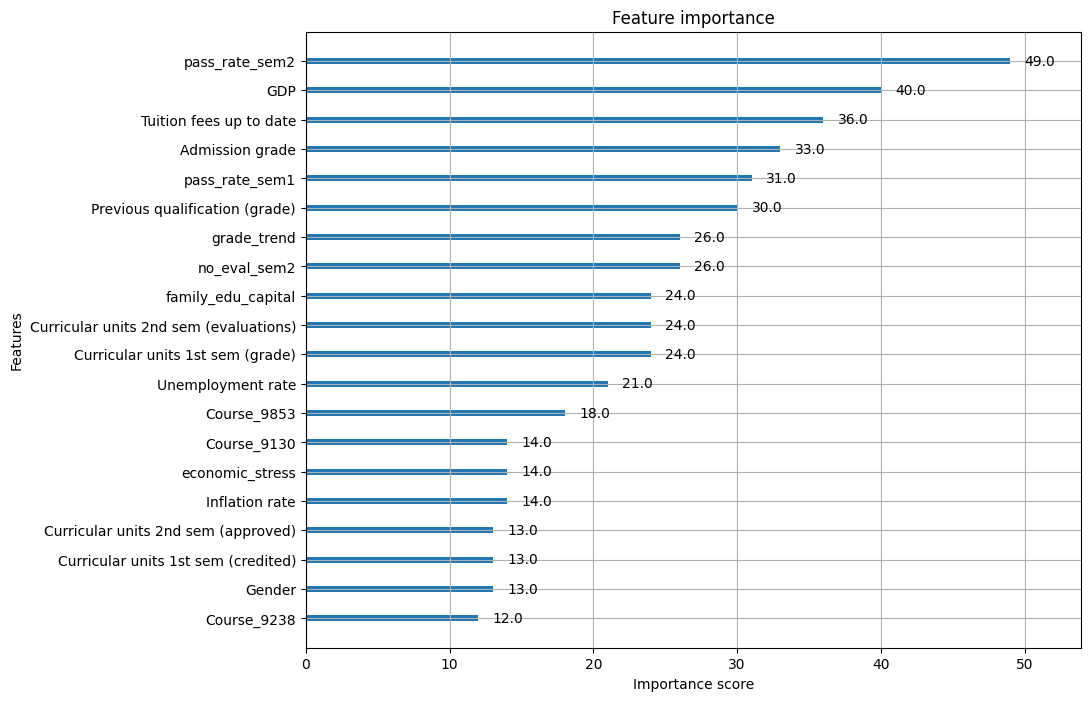

In [11]:
import os

from xgboost import plot_importance
fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(best_xgb_model, max_num_features=20, ax=ax) # max_num_features 指定显示数量

save_path = '/content/drive/MyDrive/Colab Notebooks/machine learning'
file_full_path = os.path.join(save_path, 'xgboost_feature_importance_2class.png')
plt.savefig(file_full_path, dpi=300, bbox_inches='tight')

plt.show()

# 3-Class XGBoost
---



## Step 4: Pridiction - Training, Testing and Evaluation




### Define Target and Features

In [12]:
def prepare_xy(df):
    X = df.drop(columns=['Target', 'Target_binary'])
    y = df['Target']
    return X, y

X_train, y_train = prepare_xy(train_df)
X_test, y_test = prepare_xy(test_df)
X_full, y_full = prepare_xy(full_df)

### Initialize and Train Baseline Model

In [13]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_multi = xgb.XGBClassifier(
    objective='multi:softprob', # 明确三分类目标
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'      # 多分类评估指标
)
xgb_multi.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3, ...)

### Evaluate Baseline Model


==================== Training Set Evaluation ====================
Accuracy:  0.9997
Precision: 0.9997
Recall:    0.9997
F1-Score:  0.9997

Detailed Classification Report:
              precision    recall  f1-score   support

     Dropout       1.00      1.00      1.00       994
    Enrolled       1.00      1.00      1.00       556
    Graduate       1.00      1.00      1.00      1546

    accuracy                           1.00      3096
   macro avg       1.00      1.00      1.00      3096
weighted avg       1.00      1.00      1.00      3096



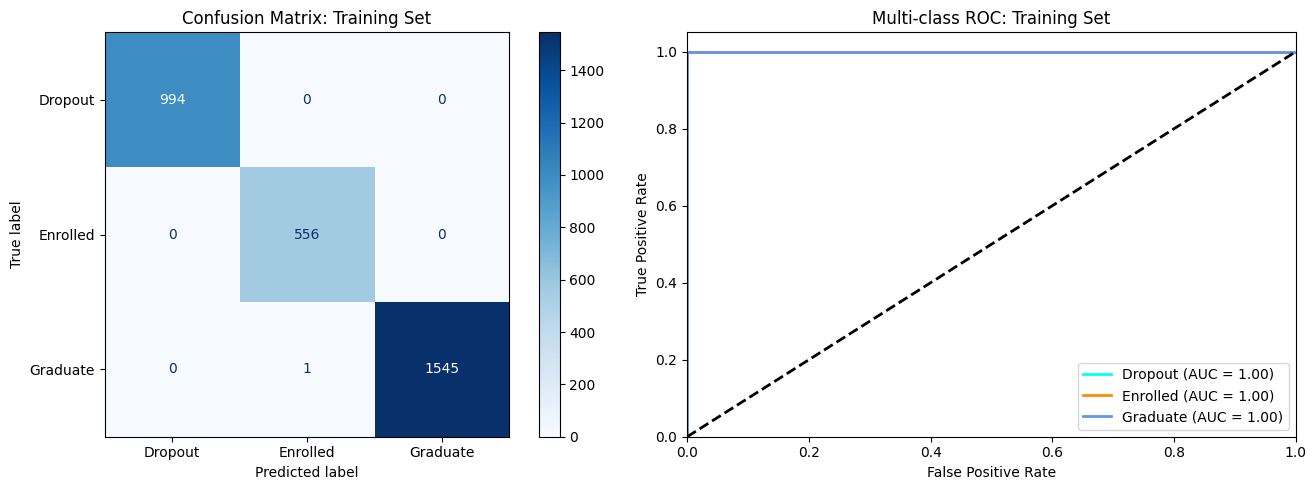


==================== Testing Set Evaluation ====================
Accuracy:  0.7545
Precision: 0.7566
Recall:    0.7545
F1-Score:  0.7550

Detailed Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.74      0.76       427
    Enrolled       0.47      0.49      0.48       238
    Graduate       0.83      0.86      0.85       663

    accuracy                           0.75      1328
   macro avg       0.70      0.70      0.70      1328
weighted avg       0.76      0.75      0.76      1328



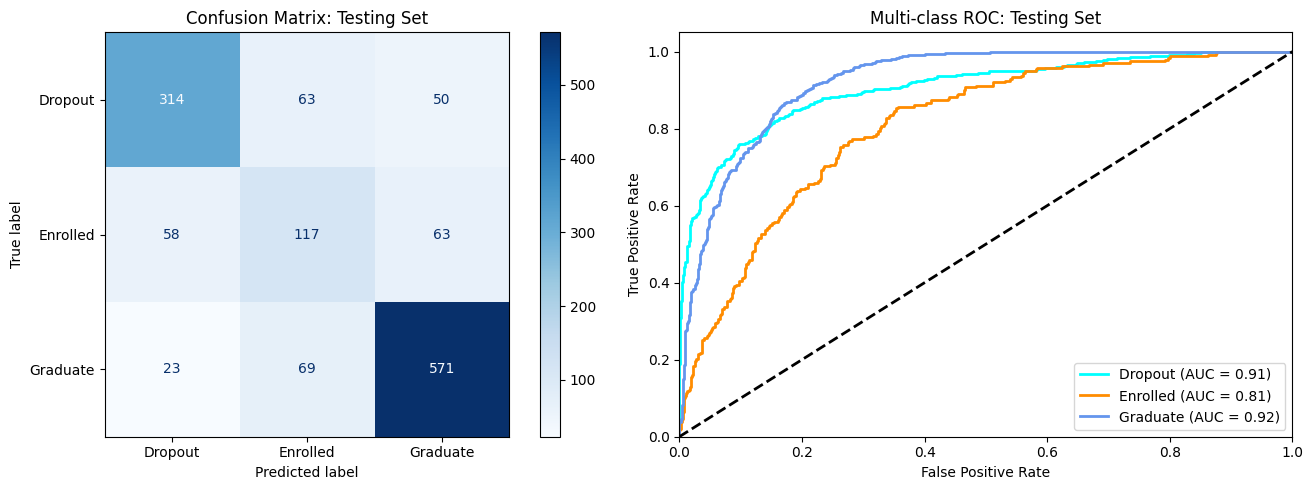


==================== Entire Set Evaluation ====================
Accuracy:  0.9261
Precision: 0.9263
Recall:    0.9261
F1-Score:  0.9262

Detailed Classification Report:
              precision    recall  f1-score   support

     Dropout       0.94      0.92      0.93      1421
    Enrolled       0.83      0.85      0.84       794
    Graduate       0.95      0.96      0.95      2209

    accuracy                           0.93      4424
   macro avg       0.91      0.91      0.91      4424
weighted avg       0.93      0.93      0.93      4424



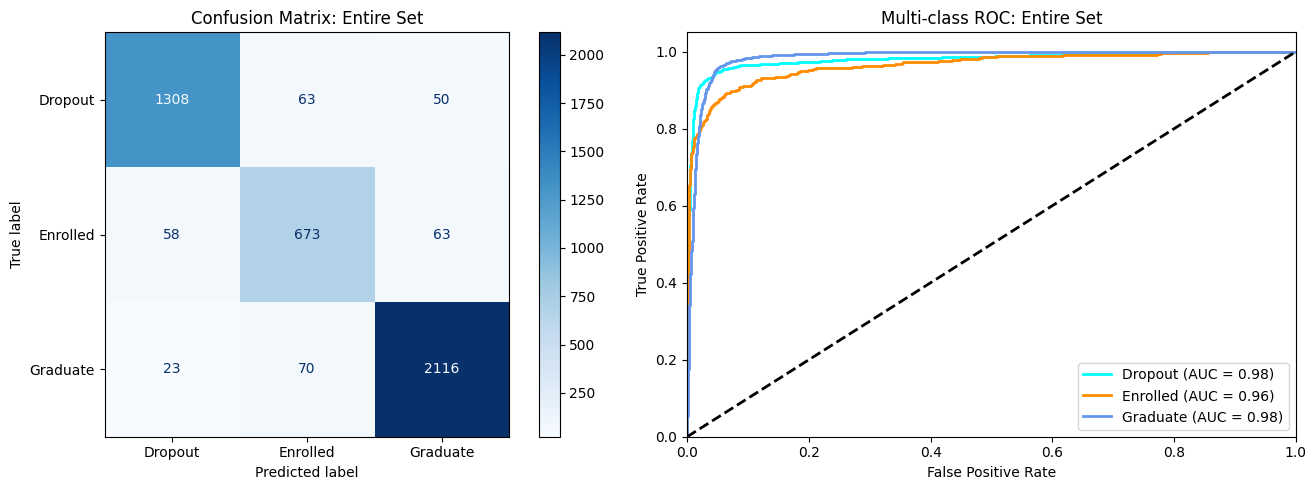


--- Summary of Model Performance ---
Training AUC:   1.0000
Testing AUC:    0.8968
Interpretation: Potential Overfitting detected (High gap between Train and Test).


In [ ]:
from sklearn.preprocessing import label_binarize

def full_evaluation(model, X, y, set_name):
    # Task 4: 获取预测值
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)

    classes = ['Dropout', 'Enrolled', 'Graduate']

    print(f"\n==================== {set_name} Evaluation ====================")

    # Task 5: 计算核心指标 [cite: 84]
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='weighted')
    rec = recall_score(y, y_pred, average='weighted')
    f1 = f1_score(y, y_pred, average='weighted')

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    # Task 4: 输出分类报告与混淆矩阵 [cite: 74, 79]
    print("\nDetailed Classification Report:")
    print(classification_report(y, y_pred, target_names=classes))

    # 绘制可视化图表 (混淆矩阵 + ROC 曲线)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Confusion Matrix [cite: 79, 84]
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap='Blues', ax=ax1)
    ax1.set_title(f"Confusion Matrix: {set_name}")

    # 2. ROC Curve & AUC
    y_bin = label_binarize(y, classes=np.unique(y))
    colors = ['aqua', 'darkorange', 'cornflowerblue']
    for i, color in enumerate(colors):
      fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
      roc_auc = auc(fpr, tpr)
      ax2.plot(fpr, tpr, color=color, lw=2, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

    ax2.plot([0, 1], [0, 1], 'k--', lw=2)
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title(f'Multi-class ROC: {set_name}')
    ax2.legend(loc="lower right")

    # 返回宏平均 AUC
    roc_auc_weighted = roc_auc_score(y, y_prob, multi_class='ovr', average='weighted')

    plt.tight_layout()
    plt.show()

    return roc_auc_weighted


train_auc = full_evaluation(xgb_multi, X_train, y_train, "Training Set")
test_auc = full_evaluation(xgb_multi, X_test, y_test, "Testing Set")
full_auc = full_evaluation(xgb_multi, X_full, y_full, "Entire Set")

print("\n--- Summary of Model Performance ---")
print(f"Training AUC:   {train_auc:.4f}")
print(f"Testing AUC:    {test_auc:.4f}")

if (train_auc - test_auc) > 0.1:
    print("Interpretation: Potential Overfitting detected (High gap between Train and Test).")
else:
    print("Interpretation: Model shows good generalization (Stable performance across sets).")

## Step 5 Hyperparameter Tuning

### Get Best Hyperparameters

In [14]:
param_grid_xgb_multi = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'gamma': [0, 0.1]
}

In [15]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(objective='multi:softprob', num_class=3, random_state=42, eval_metric='mlogloss'),
    param_grid=param_grid_xgb_multi,
    cv=5,
    scoring='f1_weighted', # 针对不平衡数据，F1 通常比 Accuracy 更好
)

grid_search.fit(X_train, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")

Best Hyperparameters: {'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300}


In [16]:
best_xgb_model = grid_search.best_estimator_

### Final Evaluation on Testing Set


==================== Testing Set Evaluation ====================
Accuracy:  0.7681
Precision: 0.7567
Recall:    0.7681
F1-Score:  0.7599

Detailed Classification Report:
              precision    recall  f1-score   support

     Dropout       0.78      0.76      0.77       427
    Enrolled       0.54      0.42      0.47       238
    Graduate       0.82      0.90      0.86       663

    accuracy                           0.77      1328
   macro avg       0.71      0.69      0.70      1328
weighted avg       0.76      0.77      0.76      1328



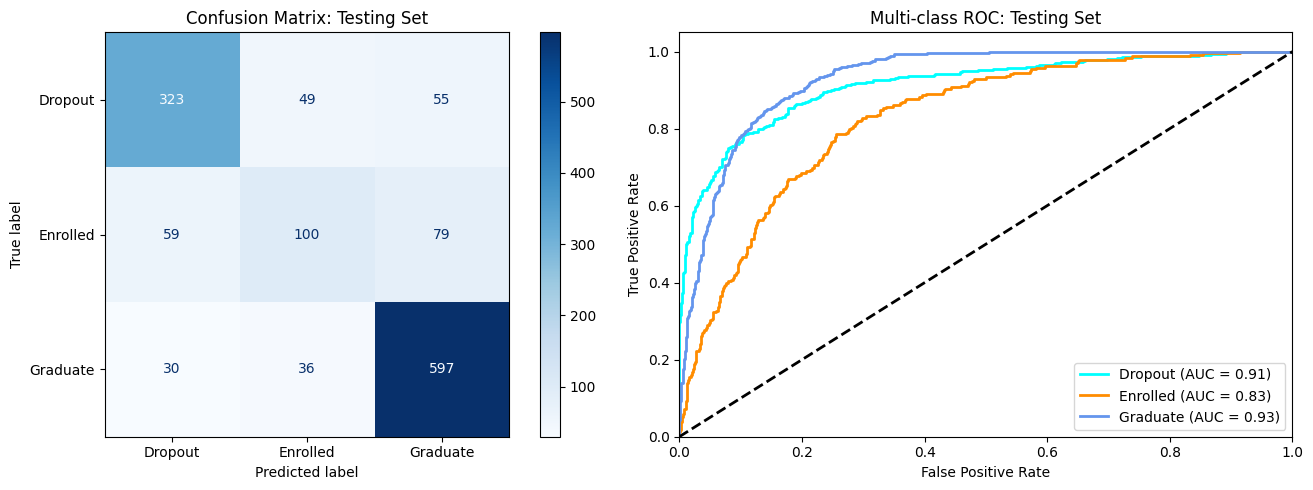

Tuned AUC:   0.9064


In [ ]:
tuned_auc = full_evaluation(best_xgb_model, X_test, y_test, "Testing Set")
print(f"Tuned AUC:   {tuned_auc:.4f}")

## Feature Importance

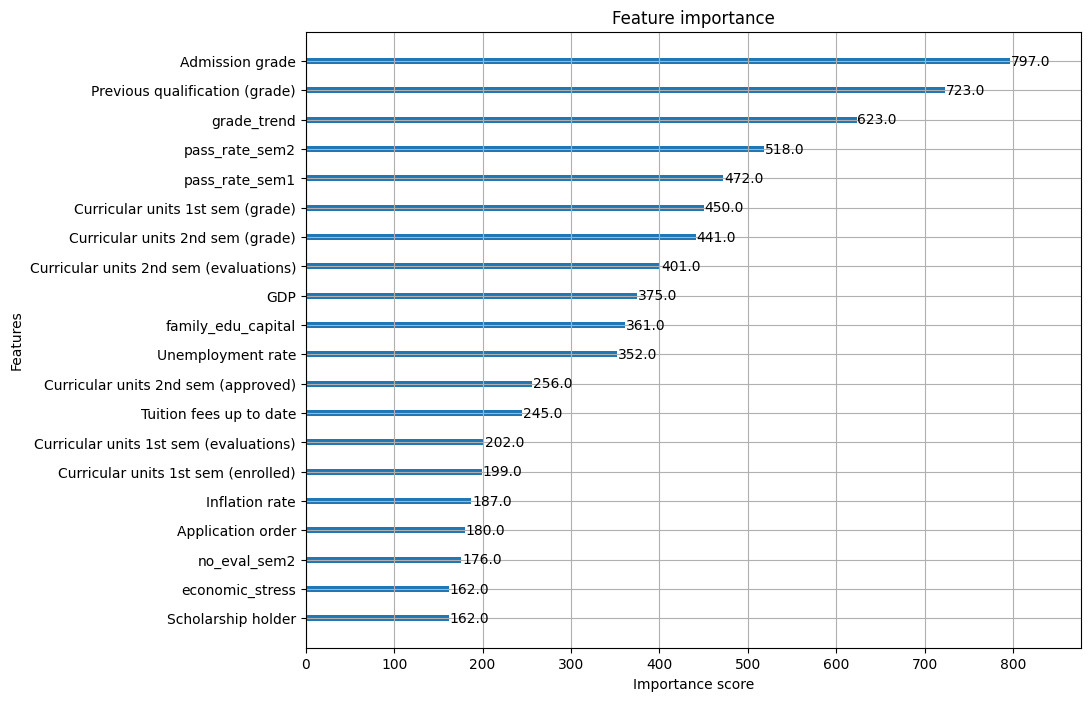

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(best_xgb_model, max_num_features=20, ax=ax) # max_num_features 指定显示数量

save_path = '/content/drive/MyDrive/Colab Notebooks/machine learning'
file_full_path = os.path.join(save_path, 'xgboost_feature_importance_3class.png')
plt.savefig(file_full_path, dpi=300, bbox_inches='tight')

plt.show()